# The Experts — School of Analytics Open Hackathon 2026
## Продуктовая аналитика и A/B-тестирование рекомендательной системы

**Команда:** К недрам Чили

### Цель исследования

Маркетплейс в течение 30 дней сравнивал две рекомендательные системы:

- `control` — старая система рекомендаций;
- `test` — новая AI-модель.

Наша задача — на основе предоставленного датасета ответить на бизнес-вопрос:

> **Стоит ли масштабировать новую рекомендательную модель, для каких пользователей она работает лучше и какие риски возникают при внедрении?**

В ноутбуке последовательно выполнены задания 1–8 из ТЗ:

1. проверка качества данных;
2. EDA;
3. анализ пользовательской воронки;
4. анализ A/B-теста;
5. сегментационный анализ;
6. бизнес-интерпретация;
7. рекомендации руководству;
8. запрос дополнительных данных.

## Подготовка окружения и загрузка данных

Ноутбук ищет CSV-файлы сначала в папке `data/`, а если её нет — в той же папке, где находится сам notebook.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chisquare, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = Path("data") if Path("data/users.csv").exists() else Path(".")

table_names = [
    "users",
    "experiment_assignments",
    "sessions",
    "impressions",
    "clicks",
    "orders",
    "products",
    "sellers",
    "premium_subscriptions",
    "support_tickets",
]

tables = {
    name: pd.read_csv(DATA_DIR / f"{name}.csv")
    for name in table_names
}

users = tables["users"]
exp = tables["experiment_assignments"]
sessions = tables["sessions"]
impressions = tables["impressions"]
clicks = tables["clicks"]
orders = tables["orders"]
products = tables["products"]
sellers = tables["sellers"]
premium = tables["premium_subscriptions"]
tickets = tables["support_tickets"]

print("Данные успешно загружены.")

Данные успешно загружены.


# 1. Проверка качества данных

Перед расчётом метрик A/B-теста проверяем:

- пропуски;
- дубли;
- уникальность ключей;
- конфликтующие назначения пользователей;
- аномальную активность;
- технические дубли событий;
- баланс экспериментальных групп;
- целостность связей между таблицами.

In [2]:
overview = pd.DataFrame({
    "table": list(tables.keys()),
    "rows": [len(df) for df in tables.values()],
    "columns": [df.shape[1] for df in tables.values()],
})
overview

,table,rows,columns
0,users,50000,8
1,experiment_assignments,50300,6
2,sessions,164739,9
3,impressions,1066434,9
4,clicks,91266,7
5,orders,7407,14
6,products,4500,8
7,sellers,700,5
8,premium_subscriptions,9127,6
9,support_tickets,337,7


### 1.1. Пропуски

In [3]:
missing_rows = []

for name, df in tables.items():
    for column, count in df.isna().sum().items():
        if count > 0:
            missing_rows.append({
                "table": name,
                "column": column,
                "missing_count": int(count),
                "missing_share_pct": count / len(df) * 100,
            })

missing_report = pd.DataFrame(missing_rows)
missing_report

,table,column,missing_count,missing_share_pct
0,orders,delivery_fee_rub,303,4.0907
1,orders,return_date,6945,93.7627


In [4]:
print("Всего заказов:", len(orders))
print("Возвратов:", int(orders["is_returned"].sum()))
print("Заполненных return_date:", int(orders["return_date"].notna().sum()))

print(
    "Возврат есть, а даты нет:",
    int(((orders["is_returned"] == 1) & orders["return_date"].isna()).sum())
)

print(
    "Возврата нет, а дата есть:",
    int(((orders["is_returned"] == 0) & orders["return_date"].notna()).sum())
)

Всего заказов: 7407
Возвратов: 462
Заполненных return_date: 462
Возврат есть, а даты нет: 0
Возврата нет, а дата есть: 0


**Интерпретация и обработка пропусков**

Пропуски разделяем на два типа.

**1. Структурные пропуски.**  
Отсутствие значения имеет бизнес-смысл. Например, `return_date` пуст у заказа,
который не был возвращён. Такой пропуск не является ошибкой и не должен
заполняться искусственной датой.

**2. Неинформативные пропуски.**  
Значение должно существовать, но по технической причине отсутствует.
В `delivery_fee_rub` отсутствует около 4% значений. Эти пропуски в аналитической
таблице не оставляем.

Для `delivery_fee_rub` применяем следующую обработку:

- сохраняем отдельный флаг `delivery_fee_was_missing`;
- заполняем пропуски медианной стоимостью доставки внутри товарной категории;
- если для категории медиана недоступна, используем общую медиану по заказам.

Замена на `0` не используется, потому что нулевая стоимость доставки встречается
как реальное значение. Медиана выбрана как более устойчивый показатель для
несимметричного распределения стоимости доставки.

### 1.2. Полные дубли и ключи

In [5]:
duplicate_report = pd.DataFrame({
    "table": list(tables.keys()),
    "full_row_duplicates": [int(df.duplicated().sum()) for df in tables.values()],
})
duplicate_report

,table,full_row_duplicates
0,users,0
1,experiment_assignments,0
2,sessions,0
3,impressions,0
4,clicks,0
5,orders,0
6,products,0
7,sellers,0
8,premium_subscriptions,0
9,support_tickets,0


In [6]:
primary_keys = {
    "users": "user_id",
    "experiment_assignments": "assignment_id",
    "sessions": "session_id",
    "impressions": "impression_id",
    "clicks": "click_id",
    "orders": "order_id",
    "products": "product_id",
    "sellers": "seller_id",
    "support_tickets": "ticket_id",
}

key_report = []

for table_name, key in primary_keys.items():
    key_report.append({
        "table": table_name,
        "key": key,
        "duplicated_key_values": int(tables[table_name][key].duplicated().sum()),
    })

pd.DataFrame(key_report)

,table,key,duplicated_key_values
0,users,user_id,0
1,experiment_assignments,assignment_id,0
2,sessions,session_id,0
3,impressions,impression_id,0
4,clicks,click_id,0
5,orders,order_id,0
6,products,product_id,0
7,sellers,seller_id,0
8,support_tickets,ticket_id,0


### 1.3. Пользователи, назначенные сразу в две группы

In [7]:
groups_per_user = exp.groupby("user_id")["experiment_group"].nunique()
cross_assigned_users = set(groups_per_user[groups_per_user > 1].index)

print("Строк в experiment_assignments:", len(exp))
print("Уникальных пользователей:", exp["user_id"].nunique())
print("Пользователей одновременно в control и test:", len(cross_assigned_users))
print(
    "Доля:",
    f"{len(cross_assigned_users) / users['user_id'].nunique() * 100:.2f}%"
)

display(exp["assignment_source"].value_counts().to_frame("rows"))

Строк в experiment_assignments: 50300
Уникальных пользователей: 50000
Пользователей одновременно в control и test: 300
Доля: 0.60%


,rows
assignment_source,
assignment_service,50000
assignment_service_bug,300


Обнаружено 300 пользователей, попавших одновременно в `control` и `test`. Дополнительные назначения маркированы `assignment_service_bug`.

Для основного анализа такие пользователи исключаются, потому что они нарушают принцип однозначного воздействия варианта эксперимента.

### 1.4. Bot candidates

In [8]:
print(users["is_bot_candidate"].value_counts().rename(index={0: "обычные", 1: "bot candidate"}))
print("Доля bot candidates:", f"{users['is_bot_candidate'].mean() * 100:.2f}%")

user_activity_check = (
    sessions.groupby("user_id")
    .agg(
        sessions_count=("session_id", "count"),
        total_page_views=("page_views", "sum"),
        avg_session_duration_sec=("session_duration_sec", "mean"),
    )
    .reset_index()
    .merge(users[["user_id", "is_bot_candidate"]], on="user_id", how="left")
)

bot_activity = (
    user_activity_check
    .groupby("is_bot_candidate")[
        ["sessions_count", "total_page_views", "avg_session_duration_sec"]
    ]
    .mean()
)

bot_activity.index = ["обычные пользователи", "bot candidates"]
bot_activity

is_bot_candidate
обычные          49600
bot candidate      400
Name: count, dtype: int64
Доля bot candidates: 0.80%


,sessions_count,total_page_views,avg_session_duration_sec
обычные пользователи,3.1916,22.3268,272.9089
bot candidates,16.0900,578.3225,820.9960


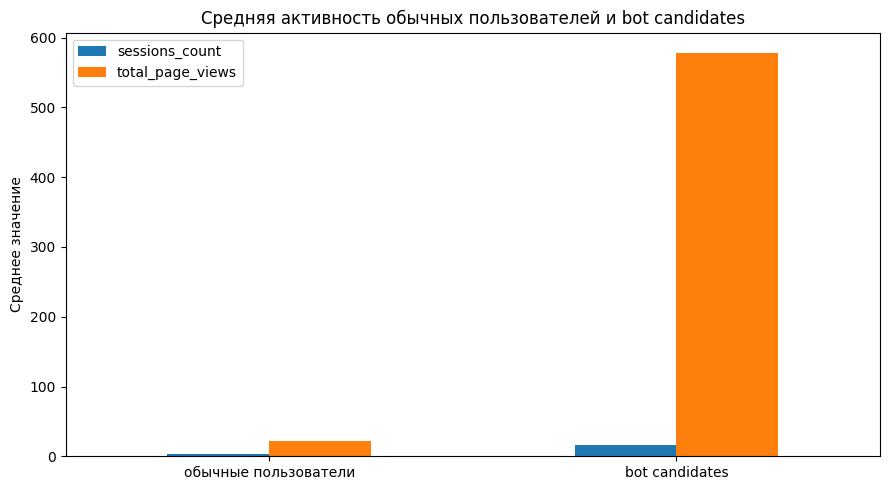

In [9]:
ax = bot_activity[["sessions_count", "total_page_views"]].plot(
    kind="bar",
    figsize=(9, 5),
)
ax.set_title("Средняя активность обычных пользователей и bot candidates")
ax.set_ylabel("Среднее значение")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Bot candidates демонстрируют кратно более высокую активность и могут непропорционально влиять на поведенческие метрики. Для основного анализа они исключаются.

### 1.5. Технические дубли показов

In [10]:
duplicate_impressions = int(impressions["is_duplicate_event"].sum())

print("Всего показов:", len(impressions))
print("is_duplicate_event = 1:", duplicate_impressions)
print("Доля:", f"{impressions['is_duplicate_event'].mean() * 100:.3f}%")

Всего показов: 1066434
is_duplicate_event = 1: 3193
Доля: 0.299%


Технически продублированные показы исключаем. Чтобы не разрывать цепочку событий, также исключаем клики и заказы, которые относятся к таким показам.

### 1.6. Проверка исходного распределения control / test

In [11]:
canonical_assignment = exp[
    exp["assignment_source"] == "assignment_service"
].copy()

group_counts = canonical_assignment["experiment_group"].value_counts()
display(group_counts.to_frame("users"))

observed = group_counts.reindex(["control", "test"]).values

srm = chisquare(
    observed,
    f_exp=[len(canonical_assignment) / 2, len(canonical_assignment) / 2]
)

print("p-value проверки 50/50:", round(float(srm.pvalue), 4))

,users
experiment_group,
test,25185
control,24815


p-value проверки 50/50: 0.098


`p-value > 0.05`: статистически значимого Sample Ratio Mismatch не обнаружено. По численности группы совместимы с ожидаемым разбиением 50/50.

### 1.7. Баланс наблюдаемых характеристик

In [12]:
balance_data = users.merge(
    canonical_assignment[["user_id", "experiment_group"]],
    on="user_id",
    how="inner",
)

balance_columns = [
    "device",
    "region",
    "age_group",
    "traffic_source",
    "is_premium",
    "is_bot_candidate",
]

balance_rows = []

for column in balance_columns:
    table = pd.crosstab(
        balance_data[column],
        balance_data["experiment_group"]
    )
    chi2, p_value, _, _ = chi2_contingency(table)

    balance_rows.append({
        "feature": column,
        "p_value": p_value,
        "difference_at_5pct": p_value < 0.05,
    })

pd.DataFrame(balance_rows)

,feature,p_value,difference_at_5pct
0,device,0.1117,False
1,region,0.5072,False
2,age_group,0.6530,False
3,traffic_source,0.2039,False
4,is_premium,0.2382,False
5,is_bot_candidate,0.7648,False


По проверенным наблюдаемым характеристикам значимого дисбаланса не обнаружено. Это поддерживает предположение о корректной исходной рандомизации.

### 1.8. Проверка связей impression → click → order

In [13]:
integrity = {
    "clicks_without_impression":
        int((~clicks["impression_id"].isin(impressions["impression_id"])).sum()),
    "orders_without_click":
        int((~orders["click_id"].isin(clicks["click_id"])).sum()),
    "impressions_without_user":
        int((~impressions["user_id"].isin(users["user_id"])).sum()),
    "sessions_without_user":
        int((~sessions["user_id"].isin(users["user_id"])).sum()),
    "orders_without_user":
        int((~orders["user_id"].isin(users["user_id"])).sum()),
}

pd.Series(integrity, name="broken_links").to_frame()

,broken_links
clicks_without_impression,0
orders_without_click,0
impressions_without_user,0
sessions_without_user,0
orders_without_user,0


In [14]:
click_imp = clicks.merge(
    impressions[
        ["impression_id", "user_id", "session_id", "product_id", "is_clicked"]
    ],
    on="impression_id",
    how="left",
    suffixes=("_click", "_imp"),
)

order_click = orders.merge(
    clicks[["click_id", "user_id", "session_id", "product_id"]],
    on="click_id",
    how="left",
    suffixes=("_order", "_click"),
)

consistency = {
    "click_vs_impression_user_mismatch":
        int((click_imp["user_id_click"] != click_imp["user_id_imp"]).sum()),
    "click_vs_impression_session_mismatch":
        int((click_imp["session_id_click"] != click_imp["session_id_imp"]).sum()),
    "click_vs_impression_product_mismatch":
        int((click_imp["product_id_click"] != click_imp["product_id_imp"]).sum()),
    "click_from_impression_not_marked_clicked":
        int((click_imp["is_clicked"] != 1).sum()),
    "order_vs_click_user_mismatch":
        int((order_click["user_id_order"] != order_click["user_id_click"]).sum()),
    "order_vs_click_session_mismatch":
        int((order_click["session_id_order"] != order_click["session_id_click"]).sum()),
    "order_vs_click_product_mismatch":
        int((order_click["product_id_order"] != order_click["product_id_click"]).sum()),
}

pd.Series(consistency, name="mismatches").to_frame()

,mismatches
click_vs_impression_user_mismatch,0
click_vs_impression_session_mismatch,0
click_vs_impression_product_mismatch,0
click_from_impression_not_marked_clicked,0
order_vs_click_user_mismatch,0
order_vs_click_session_mismatch,0
order_vs_click_product_mismatch,0


### 1.9. Формирование очищенной когорты

In [15]:
bot_users = set(users.loc[users["is_bot_candidate"] == 1, "user_id"])
excluded_users = cross_assigned_users | bot_users

clean_user_ids = set(users["user_id"]) - excluded_users

clean_users = users[users["user_id"].isin(clean_user_ids)].copy()

clean_assignments = canonical_assignment[
    canonical_assignment["user_id"].isin(clean_user_ids)
][["user_id", "experiment_group"]].copy()

group_map = clean_assignments.set_index("user_id")["experiment_group"]

clean_sessions = sessions[
    sessions["user_id"].isin(clean_user_ids)
].copy()

clean_impressions = impressions[
    impressions["user_id"].isin(clean_user_ids)
    & (impressions["is_duplicate_event"] == 0)
].copy()

valid_impression_ids = set(clean_impressions["impression_id"])

clean_clicks = clicks[
    clicks["user_id"].isin(clean_user_ids)
    & clicks["impression_id"].isin(valid_impression_ids)
].copy()

valid_click_ids = set(clean_clicks["click_id"])

clean_orders = orders[
    orders["user_id"].isin(clean_user_ids)
    & orders["click_id"].isin(valid_click_ids)
].copy()

valid_order_ids = set(clean_orders["order_id"])

clean_tickets = tickets[
    tickets["user_id"].isin(clean_user_ids)
    & tickets["order_id"].isin(valid_order_ids)
].copy()

clean_premium = premium[
    premium["user_id"].isin(clean_user_ids)
].copy()

for df in [
    clean_sessions,
    clean_impressions,
    clean_clicks,
    clean_orders,
    clean_tickets,
    clean_premium,
]:
    df["experiment_group"] = df["user_id"].map(group_map)

print("Исключено уникальных пользователей:", len(excluded_users))
print("Осталось пользователей:", len(clean_users))
display(clean_assignments["experiment_group"].value_counts().to_frame("users"))

print("Чистых показов:", len(clean_impressions))
print("Чистых кликов:", len(clean_clicks))
print("Чистых заказов:", len(clean_orders))

print(
    "Пропусков delivery_fee_rub в clean_orders:",
    int(clean_orders["delivery_fee_rub"].isna().sum())
)


Исключено уникальных пользователей: 699
Осталось пользователей: 49301


,users
experiment_group,
test,24828
control,24473


Чистых показов: 1015160
Чистых кликов: 82916
Чистых заказов: 7302
Пропусков delivery_fee_rub в clean_orders: 300


### Вывод по заданию 1

Данные пригодны для дальнейшего анализа после очистки и обработки пропусков.

Основные выявленные проблемы и решения:

- 300 пользователей с конфликтующим назначением в `control` и `test` исключены;
- 400 bot candidates с аномально высокой активностью исключены;
- 3193 технически продублированных показа исключены вместе со связанными событиями;
- 303 пропуска `delivery_fee_rub` **заполнены медианой по категории товара**;
- факт исходного пропуска сохранён в `delivery_fee_was_missing`;
- пустой `return_date` у невозвращённых заказов является структурным пропуском
  и не заполняется искусственным значением;
- нарушений связей `impression → click → order` не обнаружено;
- группы `control` и `test` сбалансированы по численности и основным
  наблюдаемым характеристикам;
- часть возвратов происходит после 30-дневного окна, что учитывается как
  ограничение при интерпретации Return Rate.

После исключения конфликтующих назначений и bot candidates остаётся
49 301 пользователь.

Таким образом, в аналитически используемом поле `delivery_fee_rub`
необработанных пропусков больше нет. Пустые значения сохраняются только там,
где отсутствие значения само по себе имеет корректный бизнес-смысл.

# 2. Исследовательский анализ данных (EDA)

Задача EDA — понять структуру аудитории, пользовательскую активность и структуру заказов до формального тестирования гипотез.

### 2.1. Структура аудитории

In [16]:
audience_summary = pd.DataFrame({
    "metric": [
        "Пользователей",
        "Premium на старте",
        "Android",
        "iOS",
        "Web",
    ],
    "value": [
        len(clean_users),
        clean_users["is_premium"].mean(),
        (clean_users["device"] == "android").mean(),
        (clean_users["device"] == "ios").mean(),
        (clean_users["device"] == "web").mean(),
    ]
})

audience_summary

,metric,value
0,Пользователей,"49,301.0000"
1,Premium на старте,0.1653
2,Android,0.5783
3,iOS,0.2695
4,Web,0.1522


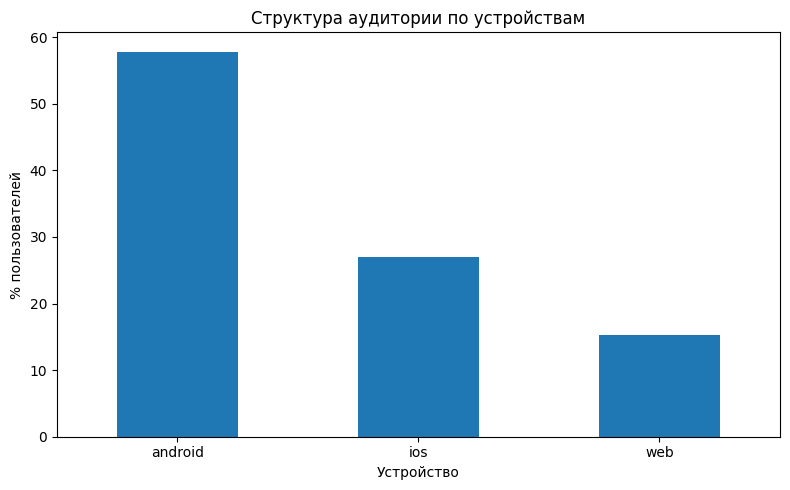

In [17]:
device_mix = (
    clean_users["device"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

ax = device_mix.plot(kind="bar", figsize=(8, 5))
ax.set_title("Структура аудитории по устройствам")
ax.set_ylabel("% пользователей")
ax.set_xlabel("Устройство")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

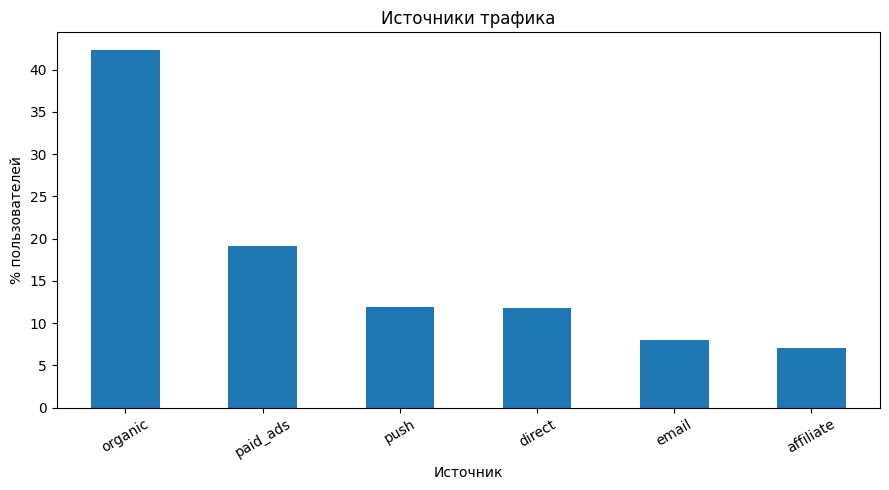

In [18]:
traffic_mix = (
    clean_users["traffic_source"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

ax = traffic_mix.plot(kind="bar", figsize=(9, 5))
ax.set_title("Источники трафика")
ax.set_ylabel("% пользователей")
ax.set_xlabel("Источник")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 2.2. Активность пользователей

In [19]:
activity = (
    clean_sessions.groupby("user_id")
    .agg(
        sessions=("session_id", "count"),
        page_views=("page_views", "sum"),
        avg_session_duration_sec=("session_duration_sec", "mean"),
    )
    .reindex(clean_users["user_id"])
    .fillna(0)
)

activity.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
sessions,"49,301.0000",3.1906,1.8099,1.0000,3.0000,4.0000,6.0000,7.0000,8.0000,16.0000
page_views,"49,301.0000",22.3182,13.3911,1.0000,20.0000,30.0000,41.0000,47.0000,61.0000,123.0000
avg_session_duration_sec,"49,301.0000",272.8904,131.9388,12.0000,249.7500,327.0000,424.0000,504.6667,732.5000,"2,370.0000"


### 2.3. Структура заказов

In [20]:
order_category = (
    clean_orders.groupby("category")
    .agg(
        orders=("order_id", "count"),
        gmv_rub=("gmv_rub", "sum"),
        margin_rub=("gross_margin_rub", "sum"),
        return_rate=("is_returned", "mean"),
    )
    .sort_values("gmv_rub", ascending=False)
)

order_category

,orders,gmv_rub,margin_rub,return_rate
category,,,,
Electronics,1079,4349240,"479,415.0600",0.0584
Fashion,1233,1921846,"385,067.6600",0.1427
Home,990,1855360,"336,560.7000",0.0657
Auto,420,1013908,"165,368.7100",0.0476
Sports,548,752347,"152,145.9900",0.0730
Kids,606,742244,"142,516.8400",0.0710
Beauty,906,727262,"198,906.1000",0.0221
Pet,449,419912,"76,139.4500",0.0334
FMCG,649,297853,"40,140.2200",0.0139


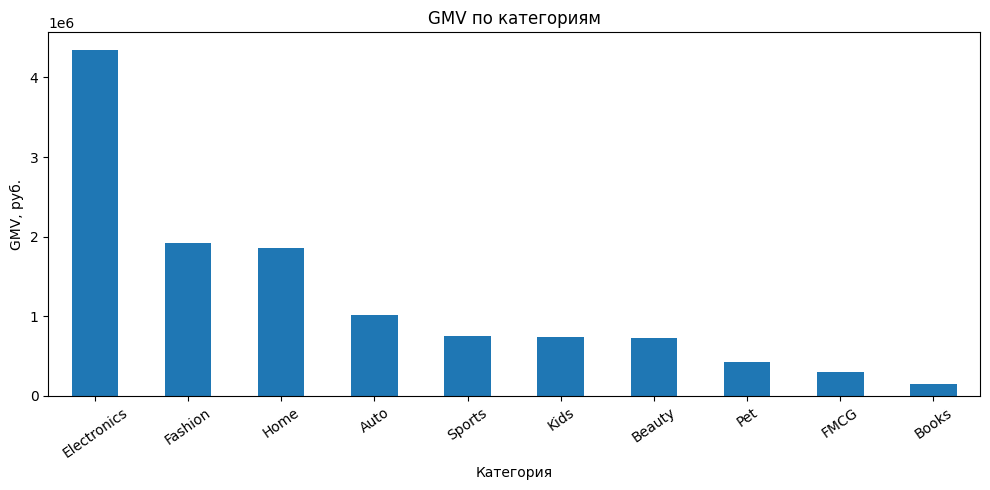

In [21]:
ax = order_category["gmv_rub"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("GMV по категориям")
ax.set_ylabel("GMV, руб.")
ax.set_xlabel("Категория")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### Вывод по EDA

- Аудитория неоднородна по устройствам, источникам трафика, Premium-статусу и региону, поэтому сегментационный анализ имеет смысл.
- Пользовательская активность имеет длинный правый хвост, поэтому предварительное исключение bot candidates важно.
- Категории существенно различаются по объёму продаж, маржинальности и возвратам; одну агрегированную бизнес-метрику недостаточно рассматривать без guardrail-метрик.

## Техническая подготовка пользовательского уровня анализа

Рандомизация происходила по пользователям, поэтому для статистических тестов важно сохранять пользователя как независимую единицу наблюдения.

In [22]:
user_level = clean_assignments.copy()

imp_ag = (
    clean_impressions.groupby("user_id")
    .agg(
        impressions=("impression_id", "count"),
        clicks=("is_clicked", "sum"),
    )
    .reset_index()
)

ord_ag = (
    clean_orders.groupby("user_id")
    .agg(
        orders=("order_id", "count"),
        gmv=("gmv_rub", "sum"),
        margin=("gross_margin_rub", "sum"),
        returns=("is_returned", "sum"),
    )
    .reset_index()
)

ticket_ag = (
    clean_tickets.groupby("user_id")
    .agg(tickets=("ticket_id", "count"))
    .reset_index()
)

user_level = (
    user_level
    .merge(imp_ag, on="user_id", how="left")
    .merge(ord_ag, on="user_id", how="left")
    .merge(ticket_ag, on="user_id", how="left")
    .merge(
        clean_users[
            [
                "user_id",
                "device",
                "region",
                "age_group",
                "traffic_source",
                "is_premium",
                "registration_date",
            ]
        ],
        on="user_id",
        how="left",
    )
)

for col in [
    "impressions",
    "clicks",
    "orders",
    "gmv",
    "margin",
    "returns",
    "tickets",
]:
    user_level[col] = user_level[col].fillna(0)

user_level["ctr_user"] = np.where(
    user_level["impressions"] > 0,
    user_level["clicks"] / user_level["impressions"],
    np.nan,
)

user_level["cto_user"] = np.where(
    user_level["clicks"] > 0,
    user_level["orders"] / user_level["clicks"],
    np.nan,
)

user_level["ordered_any"] = (user_level["orders"] > 0).astype(int)
user_level["clicked_any"] = (user_level["clicks"] > 0).astype(int)
user_level["repeat_any"] = (user_level["orders"] >= 2).astype(int)
user_level["support_any"] = (user_level["tickets"] > 0).astype(int)

user_level["aov_user"] = np.where(
    user_level["orders"] > 0,
    user_level["gmv"] / user_level["orders"],
    np.nan,
)

user_level["return_rate_user"] = np.where(
    user_level["orders"] > 0,
    user_level["returns"] / user_level["orders"],
    np.nan,
)

user_level["registration_date"] = pd.to_datetime(
    user_level["registration_date"]
)

user_level["tenure_days"] = (
    pd.Timestamp("2026-07-01") - user_level["registration_date"]
).dt.days

user_level["tenure_segment"] = pd.cut(
    user_level["tenure_days"],
    bins=[-np.inf, 30, 90, 180, 365, np.inf],
    labels=["<=30d", "31-90d", "91-180d", "181-365d", ">365d"],
)

premium_work = clean_premium.copy()
premium_work["premium_start_date"] = pd.to_datetime(
    premium_work["premium_start_date"]
)

premium_conversion_users = set(
    premium_work.loc[
        premium_work["premium_start_date"].between(
            "2026-07-01",
            "2026-07-30",
        ),
        "user_id",
    ]
)

user_level["premium_eligible"] = user_level["is_premium"] == 0
user_level["premium_converted"] = (
    user_level["user_id"].isin(premium_conversion_users)
).astype(int)

user_level.head()

,user_id,experiment_group,impressions,clicks,orders,gmv,margin,returns,tickets,device,region,age_group,traffic_source,is_premium,registration_date,ctr_user,cto_user,ordered_any,clicked_any,repeat_any,support_any,aov_user,return_rate_user,tenure_days,tenure_segment,premium_eligible,premium_converted
0,u_000001,control,15.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,android,Volga,18-24,paid_ads,0,2026-04-29,0.0667,0.0000,0,1,0,0,NaN,NaN,63,31-90d,True,0
1,u_000002,test,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,android,Central Russia,35-44,direct,0,2026-02-25,0.0000,NaN,0,0,0,0,NaN,NaN,126,91-180d,True,0
2,u_000003,control,21.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,web,Moscow,18-24,push,1,2026-04-01,0.0476,0.0000,0,1,0,0,NaN,NaN,91,91-180d,False,0
3,u_000004,control,14.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,ios,Ural,25-34,paid_ads,0,2026-03-08,0.0000,NaN,0,0,0,0,NaN,NaN,115,91-180d,True,0
4,u_000005,test,25.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,android,Central Russia,18-24,organic,1,2025-07-28,0.0400,0.0000,0,1,0,0,NaN,NaN,338,181-365d,False,0


# 3. Анализ пользовательской воронки

Рассматриваем два представления воронки:

### Событийная воронка

`Показ → Клик → Заказ`

Она отвечает на вопрос, насколько эффективно каждый показ превращается в действие.

### Пользовательская воронка

`Пользователь с показом → Пользователь с кликом → Покупатель → Повторный покупатель`

Возврат анализируется отдельно как **негативный outcome**, а не как желательный этап конверсии.

In [23]:
funnel_rows = []

for group in ["control", "test"]:
    imp_g = clean_impressions[
        clean_impressions["experiment_group"] == group
    ]
    click_g = clean_clicks[
        clean_clicks["experiment_group"] == group
    ]
    order_g = clean_orders[
        clean_orders["experiment_group"] == group
    ]

    total_users = (
        clean_assignments["experiment_group"] == group
    ).sum()

    order_counts = order_g.groupby("user_id")["order_id"].nunique()

    funnel_rows.append({
        "group": group,
        "users": total_users,
        "impressions": len(imp_g),
        "clicks": len(click_g),
        "orders": len(order_g),
        "users_with_impression": imp_g["user_id"].nunique(),
        "users_with_click": click_g["user_id"].nunique(),
        "buyers": order_g["user_id"].nunique(),
        "repeat_buyers": int((order_counts >= 2).sum()),
        "returned_orders": int(order_g["is_returned"].sum()),
    })

funnel = pd.DataFrame(funnel_rows).set_index("group")
funnel

,users,impressions,clicks,orders,users_with_impression,users_with_click,buyers,repeat_buyers,returned_orders
group,,,,,,,,,
control,24473,504604,36851,3098,24472,17488,2881,203,172
test,24828,510556,46065,4204,24828,19238,3759,404,288


In [24]:
funnel_metrics = pd.DataFrame(index=["control", "test"])

funnel_metrics["CTR"] = (
    funnel["clicks"] / funnel["impressions"]
)

funnel_metrics["Click_to_Order"] = (
    funnel["orders"] / funnel["clicks"]
)

funnel_metrics["Order_per_Impression"] = (
    funnel["orders"] / funnel["impressions"]
)

funnel_metrics["User_Click_Rate"] = (
    funnel["users_with_click"] / funnel["users_with_impression"]
)

funnel_metrics["User_Click_to_Order"] = (
    funnel["buyers"] / funnel["users_with_click"]
)

funnel_metrics["Purchase_Rate"] = (
    funnel["buyers"] / funnel["users"]
)

funnel_metrics["Return_Rate"] = (
    funnel["returned_orders"] / funnel["orders"]
)

funnel_metrics["Repeat_Buyer_Rate"] = (
    funnel["repeat_buyers"] / funnel["buyers"]
)

funnel_compare = funnel_metrics.T.copy()
funnel_compare["relative_lift_pct"] = (
    funnel_compare["test"] / funnel_compare["control"] - 1
) * 100

funnel_compare

,control,test,relative_lift_pct
CTR,0.0730,0.0902,23.5461
Click_to_Order,0.0841,0.0913,8.5574
Order_per_Impression,0.0061,0.0082,34.1185
User_Click_Rate,0.7146,0.7749,8.4295
User_Click_to_Order,0.1647,0.1954,18.6067
Purchase_Rate,0.1177,0.1514,28.6099
Return_Rate,0.0555,0.0685,23.3908
Repeat_Buyer_Rate,0.0705,0.1075,52.5303


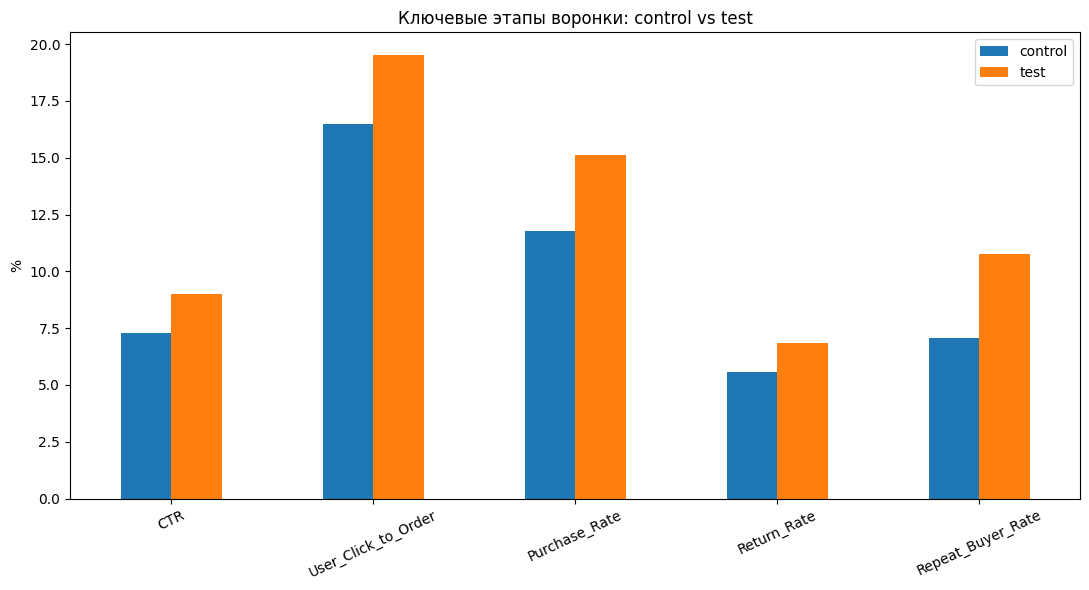

In [25]:
plot_rates = funnel_compare.loc[
    [
        "CTR",
        "User_Click_to_Order",
        "Purchase_Rate",
        "Return_Rate",
        "Repeat_Buyer_Rate",
    ],
    ["control", "test"],
].mul(100)

ax = plot_rates.plot(kind="bar", figsize=(11, 6))
ax.set_title("Ключевые этапы воронки: control vs test")
ax.set_ylabel("%")
ax.set_xlabel("")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Интерпретация воронки

Новая модель улучшает верхнюю и среднюю часть воронки:

- CTR заметно выше;
- больше пользователей вообще совершают клик;
- конверсия клика в покупку также растёт;
- доля покупателей среди всей аудитории увеличивается;
- повторных покупателей становится больше.

Однако одновременно повышается доля возвратов. Это первый сигнал, что рост вовлечённости и продаж необходимо сопоставлять с качеством покупок и операционными издержками.

# 4. Анализ результатов A/B-теста

## Методология

Так как рандомизация проводится на уровне `user_id`, статистические выводы строятся на пользовательском уровне.

Используем:

- **Welch t-test** для пользовательских непрерывных/ratio-метрик;
- **two-proportion z-test** для бинарных пользовательских конверсий;
- **95% доверительные интервалы** для разницы между группами;
- **Benjamini–Hochberg FDR correction** для одновременной проверки нескольких продуктовых метрик.

Это снижает риск ложноположительных выводов при множественном тестировании.

> AOV и Return Rate рассчитываются среди покупателей. Поскольку сам факт покупки зависит от воздействия, эти метрики интерпретируются как вторичные/диагностические, а основными бизнес-метриками считаются GMV и Gross Margin **на рандомизированного пользователя**.

In [26]:
def welch_result(metric, eligibility=None):
    control = user_level[user_level["experiment_group"] == "control"]
    test = user_level[user_level["experiment_group"] == "test"]

    if eligibility is not None:
        control = control[eligibility(control)]
        test = test[eligibility(test)]

    control_values = control[metric].dropna().astype(float)
    test_values = test[metric].dropna().astype(float)

    test_result = stats.ttest_ind(
        test_values,
        control_values,
        equal_var=False,
    )

    diff = test_values.mean() - control_values.mean()

    var_test = test_values.var(ddof=1) / len(test_values)
    var_control = control_values.var(ddof=1) / len(control_values)

    se = np.sqrt(var_test + var_control)

    df_welch = (
        (var_test + var_control) ** 2
        / (
            var_test ** 2 / (len(test_values) - 1)
            + var_control ** 2 / (len(control_values) - 1)
        )
    )

    critical = stats.t.ppf(0.975, df_welch)

    return {
        "control": control_values.mean(),
        "test": test_values.mean(),
        "effect": diff,
        "ci_low": diff - critical * se,
        "ci_high": diff + critical * se,
        "p_value": test_result.pvalue,
        "method": "Welch t-test",
    }


def proportion_result(success_col, eligibility=None):
    control = user_level[user_level["experiment_group"] == "control"]
    test = user_level[user_level["experiment_group"] == "test"]

    if eligibility is not None:
        control = control[eligibility(control)]
        test = test[eligibility(test)]

    control_success = int(control[success_col].sum())
    test_success = int(test[success_col].sum())

    control_n = len(control)
    test_n = len(test)

    _, p_value = proportions_ztest(
        [test_success, control_success],
        [test_n, control_n],
    )

    control_rate = control_success / control_n
    test_rate = test_success / test_n
    diff = test_rate - control_rate

    se = np.sqrt(
        test_rate * (1 - test_rate) / test_n
        + control_rate * (1 - control_rate) / control_n
    )

    return {
        "control": control_rate,
        "test": test_rate,
        "effect": diff,
        "ci_low": diff - 1.96 * se,
        "ci_high": diff + 1.96 * se,
        "p_value": p_value,
        "method": "Two-proportion z-test",
    }

In [27]:
metric_results = []

metric_specs = [
    (
        "User CTR",
        welch_result("ctr_user"),
        "ratio",
    ),
    (
        "Click-to-Order",
        welch_result(
            "cto_user",
            lambda df: df["clicks"] > 0,
        ),
        "ratio",
    ),
    (
        "Average Order Value",
        welch_result(
            "aov_user",
            lambda df: df["orders"] > 0,
        ),
        "rub",
    ),
    (
        "GMV per user",
        welch_result("gmv"),
        "rub",
    ),
    (
        "Gross Margin per user",
        welch_result("margin"),
        "rub",
    ),
    (
        "Return Rate",
        welch_result(
            "return_rate_user",
            lambda df: df["orders"] > 0,
        ),
        "ratio",
    ),
    (
        "Premium Conversion",
        proportion_result(
            "premium_converted",
            lambda df: df["premium_eligible"],
        ),
        "ratio",
    ),
    (
        "Customer Support Rate",
        proportion_result("support_any"),
        "ratio",
    ),
    (
        "Repeat Buyer Rate",
        proportion_result("repeat_any"),
        "ratio",
    ),
]

for metric_name, result, unit in metric_specs:
    row = {
        "metric": metric_name,
        **result,
        "unit": unit,
    }

    row["relative_lift_pct"] = (
        row["test"] / row["control"] - 1
    ) * 100

    metric_results.append(row)

ab_results = pd.DataFrame(metric_results)

ab_results["p_value_fdr"] = multipletests(
    ab_results["p_value"],
    method="fdr_bh",
)[1]

ab_results["significant_fdr_5pct"] = (
    ab_results["p_value_fdr"] < 0.05
)

ab_results[
    [
        "metric",
        "control",
        "test",
        "relative_lift_pct",
        "effect",
        "ci_low",
        "ci_high",
        "p_value",
        "p_value_fdr",
        "significant_fdr_5pct",
        "method",
    ]
]

,metric,control,test,relative_lift_pct,effect,ci_low,ci_high,p_value,p_value_fdr,significant_fdr_5pct,method
0,User CTR,0.0753,0.0932,23.8948,0.0180,0.0166,0.0194,0.0000,0.0000,True,Welch t-test
1,Click-to-Order,0.0837,0.0894,6.8050,0.0057,0.0012,0.0102,0.0131,0.0168,True,Welch t-test
2,Average Order Value,"1,656.5488","1,696.7464",2.4266,40.1976,-37.6740,118.0692,0.3116,0.3116,False,Welch t-test
3,GMV per user,209.8033,285.5786,36.1173,75.7752,59.7300,91.8205,0.0000,0.0000,True,Welch t-test
4,Gross Margin per user,34.9612,46.1364,31.9644,11.1752,8.5992,13.7511,0.0000,0.0000,True,Welch t-test
5,Return Rate,0.0550,0.0683,24.2016,0.0133,0.0020,0.0246,0.0210,0.0237,True,Welch t-test
6,Premium Conversion,0.0181,0.0236,30.0932,0.0055,0.0027,0.0082,0.0001,0.0002,True,Two-proportion z-test
7,Customer Support Rate,0.0054,0.0081,51.2412,0.0027,0.0013,0.0042,0.0002,0.0003,True,Two-proportion z-test
8,Repeat Buyer Rate,0.0083,0.0163,96.1692,0.0080,0.0060,0.0099,0.0000,0.0000,True,Two-proportion z-test


### Ключевые статистические выводы

По основной пользовательской выборке:

- **User CTR** значительно растёт;
- **Click-to-Order** растёт;
- **GMV per user** растёт примерно на треть;
- **Gross Margin per user** также значительно растёт;
- **Premium Conversion** растёт;
- **Repeat Buyer Rate** растёт;
- изменение **AOV** статистически не подтверждено;
- **Return Rate** значимо ухудшается;
- **Customer Support Rate** значимо ухудшается.

Таким образом, новый алгоритм создаёт реальную экономическую ценность, но одновременно повышает нагрузку, связанную с возвратами и поддержкой.

### 4.1. Дополнительная бизнес-сводка

In [28]:
business_summary_rows = []

for group in ["control", "test"]:
    orders_g = clean_orders[
        clean_orders["experiment_group"] == group
    ]
    tickets_g = clean_tickets[
        clean_tickets["experiment_group"] == group
    ]
    users_g = clean_assignments[
        clean_assignments["experiment_group"] == group
    ]

    n_users = len(users_g)

    business_summary_rows.append({
        "group": group,
        "users": n_users,
        "orders": len(orders_g),
        "buyers": orders_g["user_id"].nunique(),
        "GMV_total_rub": orders_g["gmv_rub"].sum(),
        "GMV_per_user_rub": orders_g["gmv_rub"].sum() / n_users,
        "AOV_rub": orders_g["gmv_rub"].mean(),
        "Gross_Margin_total_rub": orders_g["gross_margin_rub"].sum(),
        "Gross_Margin_per_user_rub":
            orders_g["gross_margin_rub"].sum() / n_users,
        "Gross_Margin_rate":
            orders_g["gross_margin_rub"].sum()
            / orders_g["gmv_rub"].sum(),
        "Return_Rate": orders_g["is_returned"].mean(),
        "Tickets_per_user": len(tickets_g) / n_users,
    })

business_summary = pd.DataFrame(
    business_summary_rows
).set_index("group")

business_summary.T

group,control,test
users,"24,473.0000","24,828.0000"
orders,"3,098.0000","4,204.0000"
buyers,"2,881.0000","3,759.0000"
GMV_total_rub,"5,134,517.0000","7,090,345.0000"
GMV_per_user_rub,209.8033,285.5786
AOV_rub,"1,657.3651","1,686.5711"
Gross_Margin_total_rub,"855,606.6400","1,145,474.9100"
Gross_Margin_per_user_rub,34.9612,46.1364
Gross_Margin_rate,0.1666,0.1616
Return_Rate,0.0555,0.0685


# 5. Сегментационный анализ

Цель — понять не только средний эффект, но и где модель работает сильнее или слабее.

Рассматриваем пользовательские сегменты:

- устройство;
- Premium status;
- стаж пользователя на платформе.

Для каждого сегмента сравниваем:

- Purchase Rate;
- Gross Margin per user;
- Support Rate;
- Return Rate среди покупателей.

Для Purchase Rate дополнительно рассчитываем статистический тест и FDR-коррекцию внутри набора сегментов.

In [29]:
def build_segment_summary(column):
    rows = []

    for segment, data in user_level.groupby(column, observed=False):
        if pd.isna(segment):
            continue

        control = data[
            data["experiment_group"] == "control"
        ]
        test = data[
            data["experiment_group"] == "test"
        ]

        if min(len(control), len(test)) < 100:
            continue

        control_success = int(control["ordered_any"].sum())
        test_success = int(test["ordered_any"].sum())

        _, purchase_p = proportions_ztest(
            [test_success, control_success],
            [len(test), len(control)],
        )

        control_buyers = control[control["orders"] > 0]
        test_buyers = test[test["orders"] > 0]

        rows.append({
            "segment_type": column,
            "segment": str(segment),
            "n_control": len(control),
            "n_test": len(test),

            "purchase_control": control["ordered_any"].mean(),
            "purchase_test": test["ordered_any"].mean(),
            "purchase_lift_pct":
                (
                    test["ordered_any"].mean()
                    / control["ordered_any"].mean()
                    - 1
                ) * 100,
            "purchase_p": purchase_p,

            "margin_per_user_control": control["margin"].mean(),
            "margin_per_user_test": test["margin"].mean(),
            "margin_lift_pct":
                (
                    test["margin"].mean()
                    / control["margin"].mean()
                    - 1
                ) * 100,

            "support_control": control["support_any"].mean(),
            "support_test": test["support_any"].mean(),

            "return_control":
                control_buyers["return_rate_user"].mean(),
            "return_test":
                test_buyers["return_rate_user"].mean(),
        })

    result = pd.DataFrame(rows)

    if len(result) > 0:
        result["purchase_p_fdr"] = multipletests(
            result["purchase_p"],
            method="fdr_bh",
        )[1]

    return result


segment_results = pd.concat(
    [
        build_segment_summary("device"),
        build_segment_summary("is_premium"),
        build_segment_summary("tenure_segment"),
    ],
    ignore_index=True,
)

segment_results

,segment_type,segment,n_control,n_test,purchase_control,purchase_test,purchase_lift_pct,purchase_p,margin_per_user_control,margin_per_user_test,margin_lift_pct,support_control,support_test,return_control,return_test,purchase_p_fdr
0,device,android,14050,14462,0.1162,0.1598,37.5713,0.0000,33.9840,48.7931,43.5766,0.0048,0.0089,0.0532,0.0669,0.0000
1,device,ios,6677,6608,0.1170,0.1421,21.4859,0.0000,36.8402,43.2672,17.4454,0.0061,0.0080,0.0442,0.0725,0.0000
2,device,web,3746,3758,0.1249,0.1354,8.4134,0.1761,35.2774,40.9579,16.1025,0.0061,0.0051,0.0791,0.0668,0.1761
3,is_premium,0,20462,20689,0.1063,0.1347,26.6283,0.0000,31.1836,40.3601,29.4271,0.0045,0.0072,0.0508,0.0674,0.0000
4,is_premium,1,4011,4139,0.1758,0.2351,33.7460,0.0000,54.2327,75.0098,38.3110,0.0097,0.0128,0.0678,0.0707,0.0000
5,tenure_segment,<=30d,2955,3019,0.1212,0.1696,39.9849,0.0000,33.9943,50.5714,48.7644,0.0044,0.0106,0.0652,0.0947,0.0000
6,tenure_segment,31-90d,4799,4760,0.1246,0.1613,29.4803,0.0000,38.6438,51.4678,33.1852,0.0058,0.0069,0.0585,0.0534,0.0000
7,tenure_segment,91-180d,5273,5393,0.1117,0.1459,30.6432,0.0000,32.2491,42.0545,30.4053,0.0046,0.0074,0.0552,0.0817,0.0000
8,tenure_segment,181-365d,6199,6317,0.1126,0.1488,32.1549,0.0000,33.5595,46.0664,37.2678,0.0050,0.0089,0.0573,0.0590,0.0000
9,tenure_segment,>365d,5247,5339,0.1216,0.1409,15.8373,0.0034,36.5194,43.0814,17.9686,0.0067,0.0075,0.0431,0.0628,0.0034


### 5.1. Эффект по устройствам

In [30]:
device_effect = segment_results[
    segment_results["segment_type"] == "device"
].copy()

device_effect[
    [
        "segment",
        "n_control",
        "n_test",
        "purchase_control",
        "purchase_test",
        "purchase_lift_pct",
        "margin_lift_pct",
        "support_control",
        "support_test",
        "return_control",
        "return_test",
        "purchase_p_fdr",
    ]
]

,segment,n_control,n_test,purchase_control,purchase_test,purchase_lift_pct,margin_lift_pct,support_control,support_test,return_control,return_test,purchase_p_fdr
0,android,14050,14462,0.1162,0.1598,37.5713,43.5766,0.0048,0.0089,0.0532,0.0669,0.0000
1,ios,6677,6608,0.1170,0.1421,21.4859,17.4454,0.0061,0.0080,0.0442,0.0725,0.0000
2,web,3746,3758,0.1249,0.1354,8.4134,16.1025,0.0061,0.0051,0.0791,0.0668,0.1761


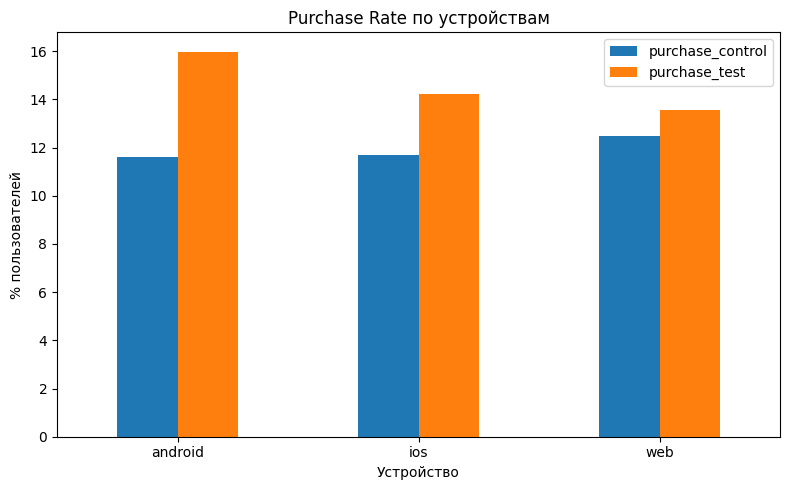

In [31]:
device_plot = (
    device_effect
    .set_index("segment")[
        ["purchase_control", "purchase_test"]
    ]
    .mul(100)
)

ax = device_plot.plot(kind="bar", figsize=(8, 5))
ax.set_title("Purchase Rate по устройствам")
ax.set_ylabel("% пользователей")
ax.set_xlabel("Устройство")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Интерпретация устройств**

- **Android** — наиболее сильный продуктовый эффект по Purchase Rate и Margin per User, но одновременно заметно растёт Support Rate.
- **iOS** — положительный эффект на покупки и маржу, однако Return Rate растёт заметнее.
- **Web** — наиболее слабый сегмент: uplift Purchase Rate небольшой и статистически не подтверждён на 5% уровне. При этом ухудшения возвратов и поддержки в этом сегменте не наблюдается.

Поэтому web является сегментом с наименьшей доказанной эффективностью новой модели.

### 5.2. Premium и стаж пользователя

In [32]:
segment_results[
    segment_results["segment_type"].isin(
        ["is_premium", "tenure_segment"]
    )
][
    [
        "segment_type",
        "segment",
        "n_control",
        "n_test",
        "purchase_lift_pct",
        "margin_lift_pct",
        "support_control",
        "support_test",
        "return_control",
        "return_test",
        "purchase_p_fdr",
    ]
]

,segment_type,segment,n_control,n_test,purchase_lift_pct,margin_lift_pct,support_control,support_test,return_control,return_test,purchase_p_fdr
3,is_premium,0,20462,20689,26.6283,29.4271,0.0045,0.0072,0.0508,0.0674,0.0000
4,is_premium,1,4011,4139,33.7460,38.3110,0.0097,0.0128,0.0678,0.0707,0.0000
5,tenure_segment,<=30d,2955,3019,39.9849,48.7644,0.0044,0.0106,0.0652,0.0947,0.0000
6,tenure_segment,31-90d,4799,4760,29.4803,33.1852,0.0058,0.0069,0.0585,0.0534,0.0000
7,tenure_segment,91-180d,5273,5393,30.6432,30.4053,0.0046,0.0074,0.0552,0.0817,0.0000
8,tenure_segment,181-365d,6199,6317,32.1549,37.2678,0.0050,0.0089,0.0573,0.0590,0.0000
9,tenure_segment,>365d,5247,5339,15.8373,17.9686,0.0067,0.0075,0.0431,0.0628,0.0034


**Интерпретация**

- Premium-пользователи дают особенно сильный абсолютный экономический эффект.
- Новые пользователи (`<=30d`) показывают высокий рост покупок и маржи, но также особенно сильный рост обращений в поддержку и возвратов.
- У пользователей со стажем `>365d` эффект на покупки слабее, хотя остаётся положительным.

### 5.3. Категории товаров как дополнительный разрез

In [33]:
impressions_category = clean_impressions.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left",
)

category_impressions = (
    impressions_category
    .groupby(["experiment_group", "category"])
    .agg(
        impressions=("impression_id", "count"),
        clicks=("is_clicked", "sum"),
    )
    .reset_index()
)

category_orders = (
    clean_orders
    .groupby(["experiment_group", "category"])
    .agg(
        orders=("order_id", "count"),
        gmv=("gmv_rub", "sum"),
        margin=("gross_margin_rub", "sum"),
        returns=("is_returned", "sum"),
    )
    .reset_index()
)

category_metrics = (
    category_impressions
    .merge(
        category_orders,
        on=["experiment_group", "category"],
        how="left",
    )
    .fillna(0)
)

category_metrics["CTR"] = (
    category_metrics["clicks"]
    / category_metrics["impressions"]
)

category_metrics["Order_per_Impression"] = (
    category_metrics["orders"]
    / category_metrics["impressions"]
)

category_metrics["Margin_per_1000_Impressions"] = (
    1000
    * category_metrics["margin"]
    / category_metrics["impressions"]
)

category_metrics["Return_Rate"] = (
    category_metrics["returns"]
    / category_metrics["orders"]
)

category_margin = category_metrics.pivot(
    index="category",
    columns="experiment_group",
    values="Margin_per_1000_Impressions",
)

category_margin["lift_pct"] = (
    category_margin["test"]
    / category_margin["control"]
    - 1
) * 100

category_margin.sort_values("lift_pct", ascending=False)

experiment_group,control,test,lift_pct
category,,,
Electronics,"2,814.7920","3,995.8428",41.9587
Books,344.1602,487.8357,41.7467
Fashion,"1,981.0766","2,729.6073",37.7840
FMCG,344.7629,462.0781,34.0278
Sports,"1,640.4349","2,173.2599",32.4807
Auto,"2,420.7524","3,098.9655",28.0166
Beauty,"1,422.1954","1,814.9031",27.6128
Kids,"1,396.3747","1,766.9188",26.5361
Pet,"1,124.3228","1,415.4327",25.8920


Во всех товарных категориях Margin per 1000 impressions увеличивается, но сила эффекта различается. При этом отдельные категории, например Fashion и Sports, требуют внимания из-за роста возвратов.

# 6. Бизнес-интерпретация результатов

Статистическая значимость сама по себе не означает, что изменение полезно бизнесу. Поэтому сопоставляем положительные и отрицательные эффекты.

In [34]:
control_gmv_user = business_summary.loc[
    "control",
    "GMV_per_user_rub",
]

test_gmv_user = business_summary.loc[
    "test",
    "GMV_per_user_rub",
]

control_margin_user = business_summary.loc[
    "control",
    "Gross_Margin_per_user_rub",
]

test_margin_user = business_summary.loc[
    "test",
    "Gross_Margin_per_user_rub",
]

n_clean = len(clean_users)

projected_incremental_gmv = (
    test_gmv_user - control_gmv_user
) * n_clean

projected_incremental_margin = (
    test_margin_user - control_margin_user
) * n_clean

margin_rate_delta_pp = (
    business_summary.loc["test", "Gross_Margin_rate"]
    - business_summary.loc["control", "Gross_Margin_rate"]
) * 100

print(
    "Оценочный прирост GMV за 30 дней при переводе всей очищенной аудитории:",
    f"{projected_incremental_gmv:,.0f} руб."
)

print(
    "Оценочный прирост Gross Margin за 30 дней:",
    f"{projected_incremental_margin:,.0f} руб."
)

print(
    "Изменение Gross Margin Rate:",
    f"{margin_rate_delta_pp:.2f} п.п."
)

Оценочный прирост GMV за 30 дней при переводе всей очищенной аудитории: 3,735,795 руб.
Оценочный прирост Gross Margin за 30 дней: 550,947 руб.
Изменение Gross Margin Rate: -0.51 п.п.


In [35]:
return_per_user = (
    clean_orders
    .groupby("experiment_group")["is_returned"]
    .sum()
    / clean_assignments[
        "experiment_group"
    ].value_counts()
)

ticket_per_user = (
    clean_tickets["experiment_group"].value_counts()
    / clean_assignments[
        "experiment_group"
    ].value_counts()
)

extra_returns_if_all_test = (
    return_per_user["test"]
    - return_per_user["control"]
) * n_clean

extra_tickets_if_all_test = (
    ticket_per_user["test"]
    - ticket_per_user["control"]
) * n_clean

print(
    "Оценочно дополнительных возвратов на 49 301 пользователей:",
    f"{extra_returns_if_all_test:,.0f}"
)

print(
    "Оценочно дополнительных обращений в поддержку:",
    f"{extra_tickets_if_all_test:,.0f}"
)

Оценочно дополнительных возвратов на 49 301 пользователей: 225
Оценочно дополнительных обращений в поддержку: 133


### Что действительно создаёт ценность

1. **GMV per user растёт** — пользователи совершают больше покупок.
2. **Gross Margin per user растёт** — эффект не ограничивается «оборотом ради оборота».
3. **Premium Conversion растёт** — появляется дополнительный долгосрочный источник выручки.
4. **Repeat Buyer Rate растёт** — новая система чаще приводит пользователя к повторной покупке.

### Что требует осторожности

1. **Return Rate растёт.**
2. **Customer Support Rate растёт.**
3. **Gross Margin Rate немного снижается**, хотя абсолютная маржа на пользователя растёт.
4. У отдельных сегментов негативные guardrail-метрики ухудшаются сильнее среднего.

### Компромисс

Новая модель создаёт больше продаж и абсолютной маржи, но часть прироста сопровождается более низким качеством покупок: пользователи чаще возвращают товары и чаще обращаются в поддержку.

Следовательно, правильная бизнес-оценка модели должна основываться не только на CTR и GMV, но и на **net contribution после стоимости возвратов и поддержки**. В предоставленном датасете полной себестоимости этих процессов нет.

### 6.1. Характер обращений в поддержку

In [36]:
support_by_reason = pd.crosstab(
    clean_tickets["reason"],
    clean_tickets["experiment_group"],
)

support_by_reason["test_minus_control"] = (
    support_by_reason.get("test", 0)
    - support_by_reason.get("control", 0)
)

support_by_reason.sort_values(
    "test_minus_control",
    ascending=False,
)

experiment_group,control,test,test_minus_control
reason,,,
product_quality,45,69,24
return_request,15,35,20
payment_issue,11,22,11
delivery_delay,34,42,8
wrong_item,15,22,7
recommendation_quality,12,11,-1


In [37]:
support_quality = (
    clean_tickets
    .groupby("experiment_group")
    .agg(
        tickets=("ticket_id", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        resolved_within_24h=(
            "resolved_within_24h",
            "mean",
        ),
    )
)

support_quality

,tickets,avg_sentiment,resolved_within_24h
experiment_group,,,
control,132,0.0748,0.7273
test,201,0.0686,0.7164


Рост обращений связан не только с качеством самой рекомендации: заметная часть тикетов относится к возвратам, качеству товара, оплате и доставке. Поэтому рост продаж сам по себе увеличивает операционную нагрузку.

При этом скорость решения тикетов и sentiment между группами меняются значительно слабее, чем частота самих обращений.

# 7. Рекомендации руководству

## Итоговая рекомендация

### Новую модель рекомендуется масштабировать, но не как одномоментный «слепой» rollout на 100% трафика.

Причины:

- экономический эффект сильный и статистически подтверждён;
- Gross Margin per User растёт примерно на треть;
- Purchase Rate, CTR, Premium Conversion и Repeat Buyer Rate улучшаются;
- положительный эффект наблюдается в большинстве крупных сегментов.

Одновременно:

- Return Rate ухудшается;
- Customer Support Rate ухудшается;
- web имеет наиболее слабое доказательство прироста Purchase Rate;
- у новых пользователей, Android и некоторых других сегментов рост операционных рисков особенно заметен.

## Практический вариант внедрения

1. **Масштабировать модель поэтапно**, сохраняя техническую возможность быстрого rollback.
2. Приоритетно масштабировать там, где экономический эффект наиболее убедителен.
3. Для web rollout проводить осторожнее: uplift Purchase Rate слабее и статистически не подтверждён.
4. Для новых пользователей и мобильных сегментов установить guardrails на:
   - Return Rate;
   - Support Rate;
   - Gross Margin per User;
   - latency / стабильность модели.
5. Отслеживать не только GMV, но и **чистую экономику после возвратов и поддержки**.
6. Сегменты с резким ростом возвратов необходимо отдельно контролировать на уровне категорий и рекомендаций.

## Риски

- рост логистических расходов из-за возвратов;
- рост нагрузки на Customer Support;
- снижение качества пользовательского опыта при «слишком агрессивных» рекомендациях;
- 30-дневный горизонт недостаточен для полноценной оценки retention и LTV;
- часть возвратов происходит после основного окна наблюдения.

# 8. Какие дополнительные данные запросить у продуктовой команды?

Перед окончательным масштабированием полезно запросить данные, которых нет в текущем датасете.

### 1. Полная unit-экономика возврата

Нужны:

- стоимость обратной логистики;
- стоимость обработки возврата;
- списания / уценка возвращённого товара;
- компенсации продавцам и покупателям.

**Зачем:** текущий `gross_margin_rub` показывает сильный положительный эффект, но без полной стоимости возврата нельзя точно оценить net contribution.

### 2. Стоимость Customer Support

Нужны:

- стоимость одного обращения;
- время работы оператора;
- канал обращения;
- эскалации.

**Зачем:** Support Rate значительно увеличивается, но денежная цена этого ухудшения неизвестна.

### 3. Причины возврата в более подробном виде

Например:

- товар не подошёл;
- ожидания не совпали с карточкой;
- импульсная покупка;
- ошибка комплектации;
- проблема доставки.

**Зачем:** это помогло бы отделить проблему рекомендательной модели от логистических и товарных проблем.

### 4. Долгосрочное поведение после эксперимента

Нужны:

- retention;
- покупки через 60/90 дней;
- churn;
- долгосрочный LTV;
- повторные возвраты.

**Зачем:** 30 дней недостаточно для оценки долгосрочной ценности пользователя.

### 5. История пользователя до эксперимента

Нужны:

- pre-period GMV;
- pre-period orders;
- pre-period activity;
- historical return rate.

**Зачем:** это позволило бы использовать CUPED / covariate adjustment, повысить статистическую мощность и дополнительно проверить сопоставимость групп.

### 6. Технические данные рекомендательной системы

Нужны:

- latency;
- ошибки/таймауты;
- доля fallback на старую модель;
- score / rank рекомендованного товара;
- причина попадания товара в рекомендацию.

**Зачем:** это позволит связать бизнес-эффект с техническим качеством и найти причины слабых сегментов.

### 7. Наличие товара и состояние каталога

Нужны:

- stock availability;
- изменение цены;
- промо;
- сроки доставки на момент показа.

**Зачем:** рекомендация может быть релевантной, но неэффективной из-за отсутствия товара, цены или плохого SLA доставки.

# Финальный Executive Summary

На очищенной выборке новая AI-рекомендательная система демонстрирует убедительный положительный эффект на коммерческие метрики:

- CTR ↑;
- Click-to-Order ↑;
- Purchase Rate ↑;
- GMV per User ↑;
- Gross Margin per User ↑;
- Premium Conversion ↑;
- Repeat Buyer Rate ↑.

AOV заметно не меняется: рост GMV создаётся главным образом за счёт **большего количества успешных покупок**, а не увеличения среднего чека.

Главный негативный эффект:

- Return Rate ↑;
- Customer Support Rate ↑.

Поэтому результат эксперимента нельзя интерпретировать как простое «CTR вырос — модель успешна».

**Рекомендация:** модель имеет достаточное основание для масштабирования, но rollout должен сопровождаться guardrail-метриками возвратов, поддержки и net contribution. Наиболее слабым по доказанному продуктовому эффекту является web; наиболее рискованными с точки зрения операционных последствий являются некоторые мобильные и новые пользовательские сегменты.

С учётом предоставленных данных вариант `reject` не выглядит рациональным: положительный эффект на абсолютную маржу статистически значим и экономически существенен.